In [5]:
import pandas as pd

df_orders = pd.read_csv('orders_raw.csv')
df_products = pd.read_csv('products.csv')

print(df_orders.shape)
df_orders.head()

(508, 11)


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [2]:
# Removing duplicate rows
df_orders.drop_duplicates(keep='first')

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2026-01-15,Siya,Bengaluru,Personal Care,18,2,80.0,Credit Card,Delivered,4.0
496,497,2026-06-05,Ayaan,Bengaluru,Personal Care,18,5,200.0,UPI,Delivered,2.0
497,498,2026-06-29,Ayaan,Bengaluru,Fruits & Vegetables,1,2,100.0,UPI,Delivered,3.0
498,499,2026-02-12,Varun,Hyderabad,Household Essentials,22,3,390.0,Debit Card,Delivered,3.0


In [6]:
# String Casing & Whitespace
df_orders['city'] = df_orders['city'].str.strip().str.title()
df_orders['category'] = df_orders['category'].str.strip().str.title()
df_orders.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [7]:
# Handling missing values
df_orders['amount_inr'] = pd.to_numeric(df_orders['amount_inr'], errors='coerce')
df_orders = df_orders.dropna(subset=['amount_inr'])

In [8]:
# Filter out outlier
df_orders = df_orders[df_orders['amount_inr'] <= 5000]

In [9]:
# Identifying the Top Category by Revenue (Delivered Orders)
delivered_orders = df_orders[df_orders['status'] == 'Delivered']
category_rev = (
    delivered_orders
    .groupby('category')['amount_inr']
    .sum()
    .reset_index()
    .sort_values(by='amount_inr', ascending=False)
)
print("Top Category by Revenue:")
print(category_rev.head(1))

Top Category by Revenue:
               category  amount_inr
3  Household Essentials     21215.0


In [10]:
# Identify Top Supplier & Zero-Order Product (Left Join)
# Left join products to orders
merged_df = pd.merge(df_products, delivered_orders, on='product_id', how='left')

# Top supplier by revenue
supplier_rev = (
    merged_df
    .groupby('supplier')['amount_inr']
    .sum()
    .reset_index()
    .sort_values(by='amount_inr', ascending=False)
)
print("\nTop Supplier by Revenue:")
print(supplier_rev.head(1))

# Verify zero-order product
zero_orders = merged_df[merged_df['order_id'].isna()]
print("\nZero-order products:")
print(zero_orders[['product_id', 'product_name']])


Top Supplier by Revenue:
                 supplier  amount_inr
6  HomeEssentials Traders     21215.0

Zero-order products:
     product_id            product_name
427          31  Premium Face Cream 50g


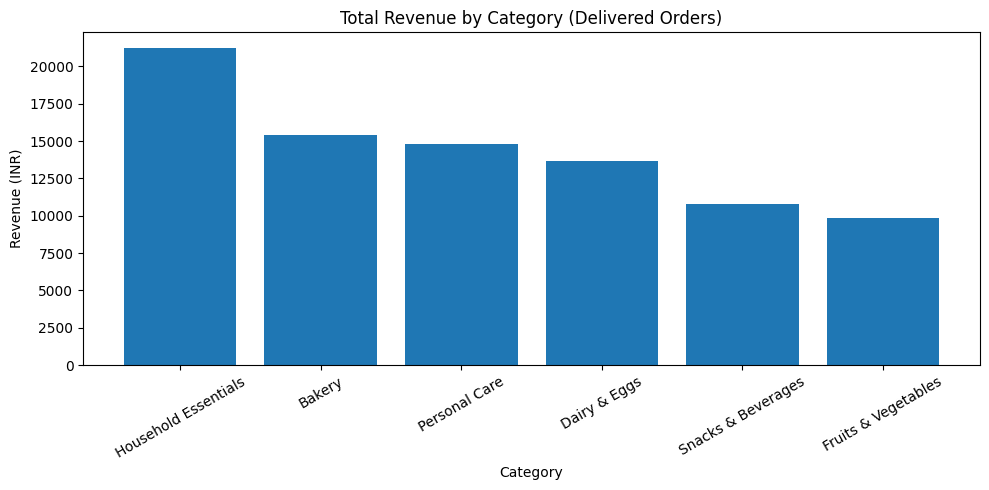

In [11]:
# Adding Visualizations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(category_rev['category'], category_rev['amount_inr'])
plt.title('Total Revenue by Category (Delivered Orders)')
plt.xlabel('Category')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()